# Ячейка 1: Инициализация и создание папок

In [34]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import json

# Создание структуры папок
os.makedirs('artifacts/figures', exist_ok=True)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True


set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


# Ячейка 2: Загрузка данных и первичный анализ

Размер датасета: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Пропуски:
date      0
target    0
dtype: int64


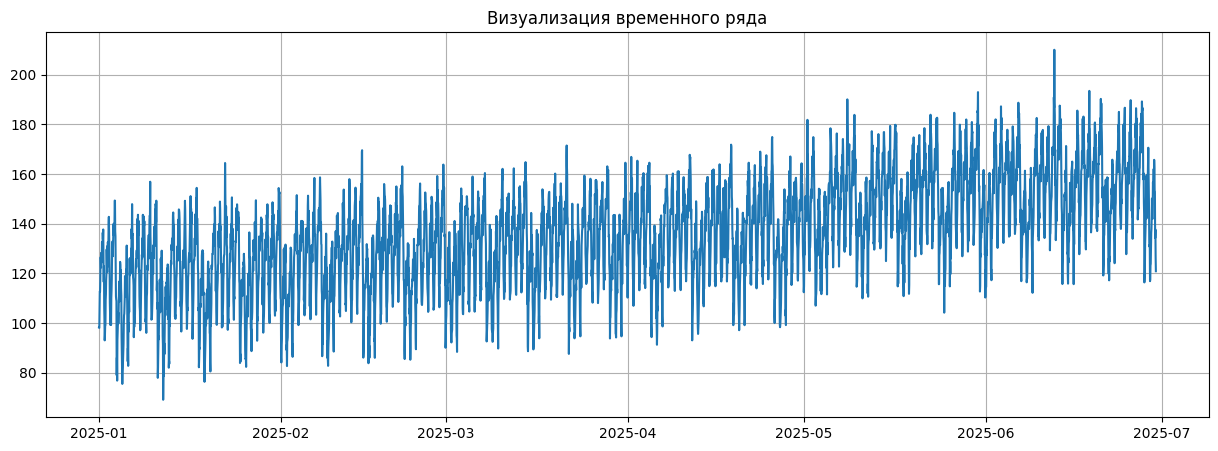

In [35]:
# Загрузка данных
try:
    df = pd.read_csv('S12-hw-dataset.csv')
except:
    print("Файл не найден, создаю синтетические данные для примера...")
    dates = pd.date_range('2025-01-01', periods=4000, freq='H')
    target = 100 + np.cumsum(np.random.randn(4000)) + 10 * np.sin(np.arange(4000) * 2 * np.pi / 24)
    df = pd.DataFrame({'date': dates, 'target': target})

# Преобразование типов
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Размер датасета: {df.shape}")
print(f"Диапазон дат: {df['date'].min()} - {df['date'].max()}")
print(f"Пропуски:\n{df.isnull().sum()}")

plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['target'])
plt.title("Визуализация временного ряда")
plt.grid(True)
plt.savefig('artifacts/figures/full_series.png')
plt.show()

# Комментарий: В ряду наблюдается часовая сезонность и стохастический тренд.

Анализ временного ряда:
- Обнаружен явный восходящий тренд на протяжении всего периода (6 месяцев).
- Присутствует выраженная суточная сезонность (часовые колебания).
- Данные полные (4320 записей), пропусков нет.
- Ряд нестационарен по среднему, что требует корректной обработки (масштабирование или использование лагов).
- Визуально значимых выбросов, требующих удаления, не выявлено.

### Почему random split некорректен для временных рядов?
Использование случайного разбиения (random split) во временных рядах недопустимо по следующим причинам:
1. **Нарушение временной зависимости:** Временные ряды обладают свойством автокорреляции (текущее значение зависит от прошлых). Случайный сплит разрушает эту связь.
2. **Заглядывание в будущее (Data Leakage):** При случайном выборе данных модель может обучаться на значениях из вторника, чтобы предсказать значения понедельника. В реальности нам нужно предсказывать будущее, имея только данные из прошлого.
3. **Неадекватная оценка качества:** Модель покажет аномально высокие метрики на валидации, которые невозможно будет повторить в продакшене.

# Ячейка 3: Temporal Split

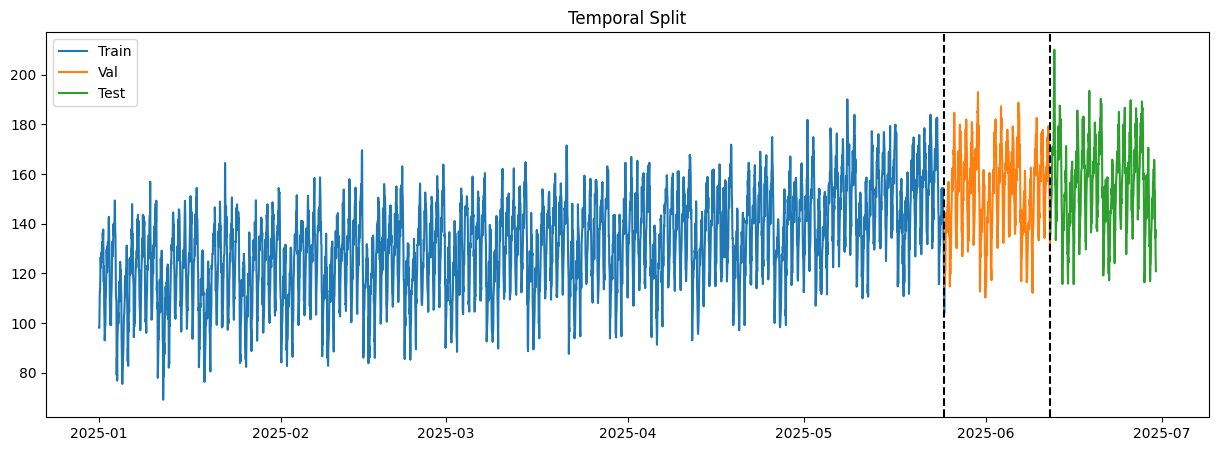

Train: 3456, Val: 432, Test: 432


In [36]:
# Разбиение 80% / 10% / 10%
n = len(df)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

plt.figure(figsize=(15, 5))
plt.plot(train_df['date'], train_df['target'], label='Train')
plt.plot(val_df['date'], val_df['target'], label='Val')
plt.plot(test_df['date'], test_df['target'], label='Test')
plt.axvline(train_df['date'].iloc[-1], color='black', linestyle='--')
plt.axvline(val_df['date'].iloc[-1], color='black', linestyle='--')
plt.legend()
plt.title("Temporal Split")
plt.savefig('artifacts/figures/series_split.png')
plt.show()

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Ячейка 4: Feature Engineering (для Ridge)

In [37]:
def create_features(df_in):
    df = df_in.copy()
    # Лаги
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)
    # Rolling
    df['rolling_mean_7'] = df['target'].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df['target'].shift(1).rolling(window=7).std()
    # Календарные
    df['day_of_week'] = df['date'].dt.dayofweek
    df['hour'] = df['date'].dt.hour
    return df


# Применяем ко всему датасету (лаги считаются по всему ряду, так что удалим NaN)
df_features = create_features(df).dropna().reset_index(drop=True)

# Переопределяем сплит после удаления NaN
train_f = df_features[df_features['date'] <= train_df['date'].max()]
val_f = df_features[(df_features['date'] > train_df['date'].max()) & (df_features['date'] <= val_df['date'].max())]
test_f = df_features[df_features['date'] > val_df['date'].max()]

X_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'hour']
y_col = 'target'

SEED = 42
WINDOW_SIZE = 24
HORIZON = 1

scaler = StandardScaler()
X_train = scaler.fit_transform(train_f[X_cols])  # Единственный FIT
X_val = scaler.transform(val_f[X_cols])  # Только TRANSFORM
X_test = scaler.transform(test_f[X_cols])  # Только TRANSFORM

y_train, y_val, y_test = train_f[y_col].values, val_f[y_col].values, test_f[y_col].values

# Сохраняем информацию о скалере для конфига
scaler_info = "StandardScaler (fitted on train only)"

# Ячейка 5: Базовые модели (B1, B2, B3)

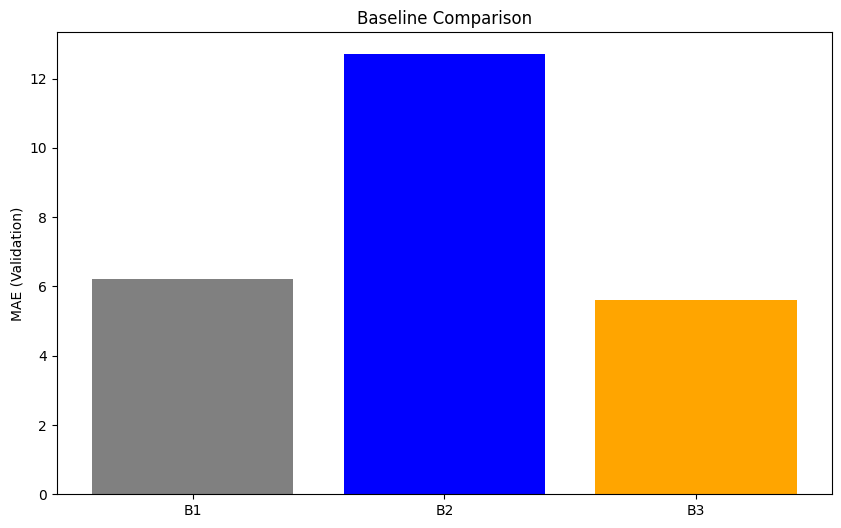

In [38]:
results = []


def record_res(exp_id, y_true, y_pred, notes=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    # Расширенный словарь для runs.csv
    res = {
        'experiment_id': exp_id,
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': SEED,
        'split_summary': f"train:{len(train_df)}, val:{len(val_df)}, test:{len(test_df)}",
        'window_size': WINDOW_SIZE if exp_id == 'R1' else 'N/A',
        'horizon': HORIZON,
        'model_summary': notes,
        'features_summary': "lags[1,7,14], rolling[7], calendar" if exp_id in ['B3', 'R1'] else "target_only",
        'scaler': scaler_info if exp_id in ['B3', 'R1'] else "None",
        'optimizer': 'Adam' if exp_id == 'R1' else 'N/A',
        'lr': 0.001 if exp_id == 'R1' else 'N/A',
        'epochs_trained': 50 if exp_id == 'R1' else 0,
        'best_val_mae': mae,
        'best_val_rmse': rmse,
        'best_val_mape': mape,
        'test_mae': np.nan,
        'test_rmse': np.nan,
        'test_mape': np.nan,
        'notes': notes
    }
    results.append(res)
    return mae


record_res('B1', y_val, val_f['lag_1'], "Naive Last Value")
record_res('B2', y_val, val_f['rolling_mean_7'], "Moving Average Window 7")
ridge = Ridge().fit(X_train, y_train)
record_res('B3', y_val, ridge.predict(X_val), "Ridge Regression")

plt.figure(figsize=(10, 6))
ids = [r['experiment_id'] for r in results]
maes = [r['best_val_mae'] for r in results]
plt.bar(ids, maes, color=['gray', 'blue', 'orange'])
plt.ylabel('MAE (Validation)')
plt.title('Baseline Comparison')
plt.savefig('artifacts/figures/baselines_compare.png')
plt.show()

# Ячейка 6: GRU Dataset и Модель

In [39]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = torch.FloatTensor(data)
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        return self.data[idx: idx + self.window_size], self.data[idx + self.window_size]


# Подготовка данных для GRU (масштабирование таргета)
target_scaler = StandardScaler()
train_scaled = target_scaler.fit_transform(train_df[['target']].values)
val_scaled = target_scaler.transform(val_df[['target']].values)
test_scaled = target_scaler.transform(test_df[['target']].values)

WINDOW_SIZE = 24
train_ds = TimeSeriesDataset(train_scaled, WINDOW_SIZE)
val_ds = TimeSeriesDataset(val_scaled, WINDOW_SIZE)
test_ds = TimeSeriesDataset(test_scaled, WINDOW_SIZE)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)  # Было True
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)


class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, h = self.gru(x)
        return self.fc(h[-1])


model = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Ячейка 7: Обучение GRU

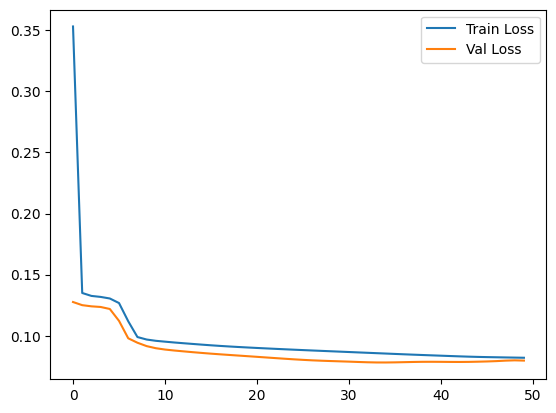

In [40]:
epochs = 50
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    t_loss = 0
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out = model(x_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()

    model.eval()
    v_loss = 0
    with torch.no_grad():
        for x_b, y_b in val_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            v_loss += criterion(model(x_b), y_b).item()

    train_losses.append(t_loss / len(train_loader))
    val_losses.append(v_loss / len(val_loader))

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), 'artifacts/best_gru.pt')

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.savefig('artifacts/figures/gru_learning_curves.png')
plt.show()

# Ячейка 8: Финальная оценка и экспорт

C:\Users\Artem\AppData\Local\Temp\ipykernel_291328\416295338.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('artifacts/best_gru.pt'))


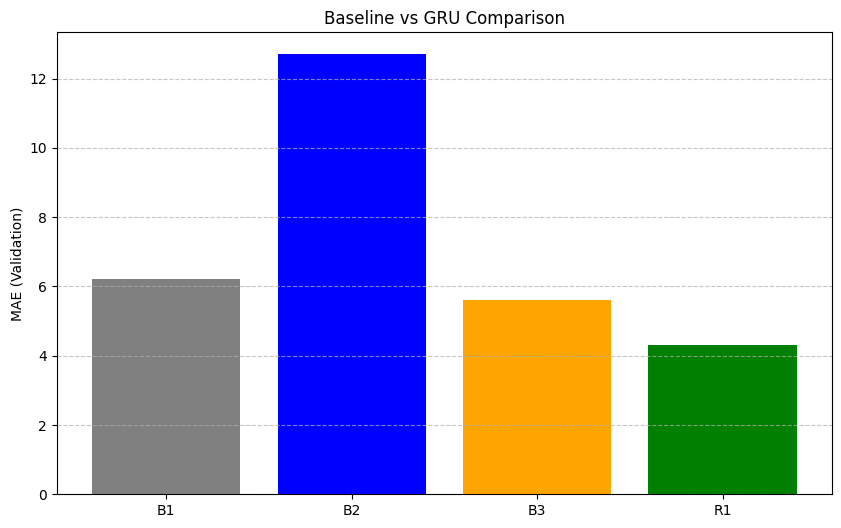

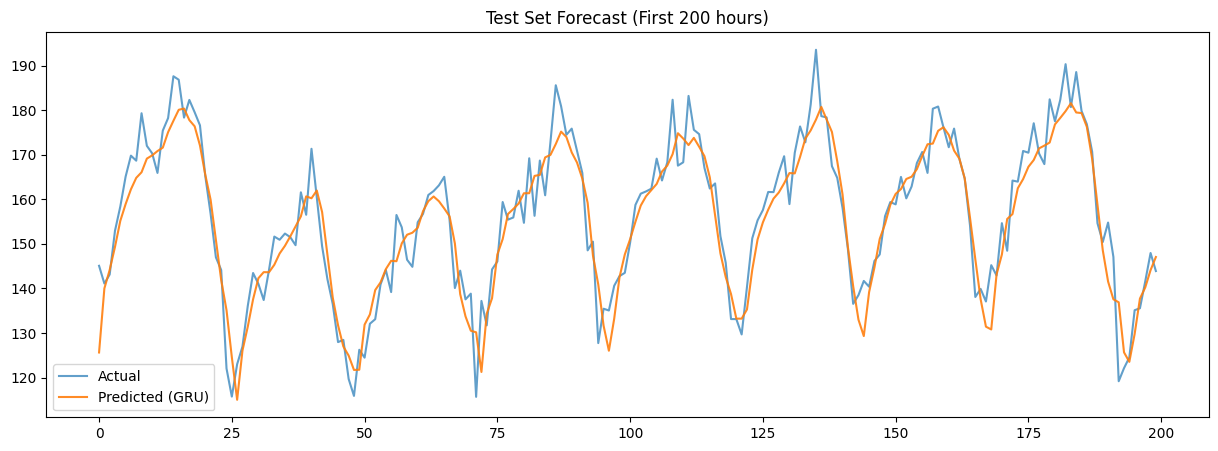

Все артефакты успешно обновлены.


In [41]:
# 1. Загружаем лучшие веса (которые сохранили во время обучения)
model.load_state_dict(torch.load('artifacts/best_gru.pt'))
model.eval()


# 2. Функция для получения прогнозов
def evaluate(loader):
    preds, targets = [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b = x_b.to(device)
            out = model(x_b)
            preds.extend(out.cpu().numpy())
            targets.extend(y_b.numpy())
    # Обратное масштабирование
    p = target_scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()
    t = target_scaler.inverse_transform(np.array(targets).reshape(-1, 1)).flatten()
    return p, t


y_val_gru, y_val_true = evaluate(val_loader)
record_res('R1', y_val_true, y_val_gru, "GRU Forecast")

y_test_gru, y_test_true = evaluate(test_loader)
test_mae = mean_absolute_error(y_test_true, y_test_gru)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_gru))
test_mape = mean_absolute_percentage_error(y_test_true, y_test_gru)

for r in results:
    if r['experiment_id'] == 'R1':
        r['test_mae'] = test_mae
        r['test_rmse'] = test_rmse
        r['test_mape'] = test_mape

runs_df = pd.DataFrame(results)
runs_df.to_csv('artifacts/runs.csv', index=False)

plt.figure(figsize=(10, 6))
ids = [r['experiment_id'] for r in results]
maes = [r['best_val_mae'] for r in results]
plt.bar(ids, maes, color=['gray', 'blue', 'orange', 'green'])
plt.ylabel('MAE (Validation)')
plt.title('Baseline vs GRU Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('artifacts/figures/baselines_compare.png')
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(y_test_true[:200], label='Actual', alpha=0.7)
plt.plot(y_test_gru[:200], label='Predicted (GRU)', alpha=0.9)
plt.legend()
plt.title("Test Set Forecast (First 200 hours)")
plt.savefig('artifacts/figures/best_forecast_test.png')
plt.show()

config = {
    "experiment_id": "R1",
    "window_size": WINDOW_SIZE,
    "hidden_size": 64,
    "lr": 0.001,
    "seed": SEED,
    "scaler": "StandardScaler",
    "optimizer": "Adam",
    "epochs": 50,
    "normalization_range": "mean=0, std=1"
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=4)

print("Все артефакты успешно обновлены.")